In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
bus = pd.read_csv('business.csv')
eco = pd.read_csv('economy.csv')
print(bus.shape,eco.shape)

(93487, 11) (206774, 11)


In [6]:
bus.head(3)

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612"
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612"
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220"


In [7]:
bus['Class'] = 'Business'
eco['Class'] = 'Economy'

In [8]:
print(bus.columns)
print(eco.columns)

Index(['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'from',
       'time_taken', 'stop', 'arr_time', 'to', 'price', 'Class'],
      dtype='str')
Index(['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'from',
       'time_taken', 'stop', 'arr_time', 'to', 'price', 'Class'],
      dtype='str')


In [9]:
print(bus.duplicated().sum())
print(eco.duplicated().sum())

0
2


In [10]:
eco.drop_duplicates(inplace=True)

In [11]:
bus.isnull().sum()

date          0
airline       0
ch_code       0
num_code      0
dep_time      0
from          0
time_taken    0
stop          0
arr_time      0
to            0
price         0
Class         0
dtype: int64

In [12]:
eco.dtypes

date            str
airline         str
ch_code         str
num_code      int64
dep_time        str
from            str
time_taken      str
stop            str
arr_time        str
to              str
price           str
Class           str
dtype: object

In [13]:
bus.dtypes

date            str
airline         str
ch_code         str
num_code      int64
dep_time        str
from            str
time_taken      str
stop            str
arr_time        str
to              str
price           str
Class           str
dtype: object

In [14]:
df = pd.concat([bus,eco])
df.shape

(300259, 12)

In [15]:
df.dtypes

date            str
airline         str
ch_code         str
num_code      int64
dep_time        str
from            str
time_taken      str
stop            str
arr_time        str
to              str
price           str
Class           str
dtype: object

In [16]:
df.sample(5)

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,Class
63718,15-02-2022,Vistara,UK,708,20:25,Kolkata,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,22:55,Hyderabad,"52,175",Business
62685,17-03-2022,Vistara,UK,772,10:25,Kolkata,10h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Bangalore,"52,287",Business
34341,25-03-2022,Air India,AI,809,10:00,Mumbai,09h 20m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,19:20,Hyderabad,"45,693",Business
87457,25-02-2022,Vistara,UK,824,20:30,Chennai,19h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,16:00,Bangalore,"63,226",Business
76804,22-02-2022,Air India,AI,541,16:15,Hyderabad,20h 15m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,12:30,Kolkata,"51,707",Business


In [17]:
df['date'] = pd.to_datetime(df['date'],format='%d-%m-%Y')

In [18]:
# dept_time, arr_time, stop, time_taken, price

In [19]:
df['stop'].unique()

<ArrowStringArray>
[                                                                   'non-stop ',
                   '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t',
            '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IDR\n\t\t\t\t\t\t\t\t\t\t\t\t',
            '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IXU\n\t\t\t\t\t\t\t\t\t\t\t\t',
        '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Chennai\n\t\t\t\t\t\t\t\t\t\t\t\t',
        '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Lucknow\n\t\t\t\t\t\t\t\t\t\t\t\t',
            '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia STV\n\t\t\t\t\t\t\t\t\t\t\t\t',
      '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Hyderabad\n\t\t\t\t\t\t\t\t\t\t\t\t',
            '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia GAY\n\t\t\t\t\t\t\t\t\t\t\t\t',
                                                                      '2+-stop',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Guwahati\n\t\t\t\t\t\t\t\t\t\t\t\t',
            '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia GAU\n\t\t\t\t\t\t\t\t\t\t\t\t',
         

In [20]:
df['arr_time'].unique()

<ArrowStringArray>
['20:00', '21:15', '20:45', '23:55', '22:00', '15:00', '17:25', '14:30',
 '08:35', '08:05',
 ...
 '04:50', '02:20', '02:50', '06:40', '06:10', '06:50', '06:30', '02:55',
 '02:15', '03:45']
Length: 266, dtype: str

In [21]:
df['dep_time'].unique()

<ArrowStringArray>
['18:00', '19:00', '20:00', '21:25', '17:15', '19:50', '21:15', '18:40',
 '20:35', '21:35',
 ...
 '04:40', '00:25', '00:45', '03:30', '23:20', '04:00', '23:40', '23:50',
 '03:55', '03:20']
Length: 251, dtype: str

In [22]:
df['time_taken'].unique()

<ArrowStringArray>
['02h 00m', '02h 15m', '24h 45m', '26h 30m', '06h 40m', '02h 10m', '17h 45m',
 '22h 45m', '17h 55m', '11h 00m',
 ...
 '36h 45m', '35h 40m', '35h 20m', '49h 50m', '47h 05m', '39h 25m', '39h 55m',
 '32h 35m', '44h 30m', '41h 30m']
Length: 483, dtype: str

In [23]:
df['price'] = df['price'].str.replace(',','')
df['price'] = pd.to_numeric(df['price'])

In [24]:
tt = df['time_taken'].values
tt

<ArrowStringArray>
['02h 00m', '02h 15m', '24h 45m', '26h 30m', '06h 40m', '02h 10m', '17h 45m',
 '22h 45m', '17h 55m', '02h 15m',
 ...
 '11h 10m', '13h 55m', '17h 15m', '10h 00m', '10h 05m', '13h 50m', '13h 50m',
 '20h 35m', '23h 20m', '24h 25m']
Length: 300259, dtype: str

In [25]:
tt_hr = [(i.split('h')[0]) for i in tt]
tt_min = [(i.split(' ')[1].split('m')[0]) for i in tt]  # 00  15  45  30 40
# tt_min

In [26]:
tt_min

['00',
 '15',
 '45',
 '30',
 '40',
 '10',
 '45',
 '45',
 '55',
 '15',
 '00',
 '15',
 '25',
 '50',
 '35',
 '00',
 '45',
 '10',
 '10',
 '20',
 '50',
 '10',
 '00',
 '30',
 '50',
 '25',
 '40',
 '25',
 '00',
 '40',
 '15',
 '35',
 '50',
 '15',
 '10',
 '00',
 '05',
 '10',
 '10',
 '15',
 '15',
 '30',
 '45',
 '30',
 '45',
 '35',
 '20',
 '15',
 '20',
 '20',
 '00',
 '35',
 '05',
 '25',
 '05',
 '55',
 '40',
 '10',
 '45',
 '30',
 '10',
 '50',
 '00',
 '55',
 '50',
 '45',
 '25',
 '40',
 '20',
 '35',
 '15',
 '25',
 '25',
 '45',
 '15',
 '00',
 '05',
 '20',
 '15',
 '35',
 '30',
 '30',
 '45',
 '25',
 '25',
 '10',
 '50',
 '25',
 '50',
 '05',
 '25',
 '45',
 '00',
 '35',
 '10',
 '10',
 '25',
 '45',
 '45',
 '40',
 '10',
 '00',
 '55',
 '35',
 '50',
 '15',
 '55',
 '55',
 '15',
 '35',
 '50',
 '55',
 '10',
 '40',
 '45',
 '15',
 '40',
 '05',
 '35',
 '25',
 '30',
 '50',
 '10',
 '00',
 '05',
 '10',
 '10',
 '15',
 '30',
 '45',
 '10',
 '15',
 '05',
 '20',
 '35',
 '35',
 '45',
 '35',
 '10',
 '30',
 '15',
 '55',
 '15',

In [27]:
df['TT_Hr'] = tt_hr
df['TT_Min'] = tt_min

In [28]:
df['dep_time'].values

<ArrowStringArray>
['18:00', '19:00', '20:00', '21:25', '17:15', '19:50', '21:15', '18:40',
 '20:35', '19:00',
 ...
 '09:45', '07:00', '06:20', '07:00', '09:45', '07:05', '07:05', '12:30',
 '09:45', '20:30']
Length: 300259, dtype: str

In [29]:
df.dtypes

date          datetime64[us]
airline                  str
ch_code                  str
num_code               int64
dep_time                 str
from                     str
time_taken               str
stop                     str
arr_time                 str
to                       str
price                  int64
Class                    str
TT_Hr                    str
TT_Min                   str
dtype: object

In [30]:
df['dep_time'] = df['dep_time'].str.split(':').str[0].astype(int)
df['arr_time'] = df['arr_time'].str.split(':').str[0].astype(int)

In [31]:
df['stop'] = df['stop'].str.replace('\n','').str.replace('\t','')

In [32]:
df['stop'].unique()

<ArrowStringArray>
[               'non-stop ',                   '1-stop',
            '1-stopVia IDR',            '1-stopVia IXU',
        '1-stopVia Chennai',        '1-stopVia Lucknow',
            '1-stopVia STV',      '1-stopVia Hyderabad',
            '1-stopVia GAY',                  '2+-stop',
       '1-stopVia Guwahati',            '1-stopVia GAU',
            '1-stopVia VTZ',            '1-stopVia NDC',
            '1-stopVia IXE',         '1-stopVia Raipur',
            '1-stopVia PAT',            '1-stopVia RPR',
          '1-stopVia Patna',        '1-stopVia Kolkata',
            '1-stopVia HYD',          '1-stopVia Delhi',
    '1-stopVia Bhubaneswar',            '1-stopVia BBI',
          '1-stopVia Surat',         '1-stopVia Indore',
            '1-stopVia GOP',         '1-stopVia Nagpur',
            '1-stopVia NAG', '1-stopVia Vishakhapatnam',
      '1-stopVia Mangalore',         '1-stopVia Mumbai',
            '1-stopVia KLH',            '1-stopVia MYQ',
       '1-st

In [33]:
df.dtypes

date          datetime64[us]
airline                  str
ch_code                  str
num_code               int64
dep_time               int64
from                     str
time_taken               str
stop                     str
arr_time               int64
to                       str
price                  int64
Class                    str
TT_Hr                    str
TT_Min                   str
dtype: object

In [34]:
df['from'].unique()

<ArrowStringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Length: 6, dtype: str

In [35]:
df['to'].unique()

<ArrowStringArray>
['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']
Length: 6, dtype: str

In [36]:
df['stop'].unique()

<ArrowStringArray>
[               'non-stop ',                   '1-stop',
            '1-stopVia IDR',            '1-stopVia IXU',
        '1-stopVia Chennai',        '1-stopVia Lucknow',
            '1-stopVia STV',      '1-stopVia Hyderabad',
            '1-stopVia GAY',                  '2+-stop',
       '1-stopVia Guwahati',            '1-stopVia GAU',
            '1-stopVia VTZ',            '1-stopVia NDC',
            '1-stopVia IXE',         '1-stopVia Raipur',
            '1-stopVia PAT',            '1-stopVia RPR',
          '1-stopVia Patna',        '1-stopVia Kolkata',
            '1-stopVia HYD',          '1-stopVia Delhi',
    '1-stopVia Bhubaneswar',            '1-stopVia BBI',
          '1-stopVia Surat',         '1-stopVia Indore',
            '1-stopVia GOP',         '1-stopVia Nagpur',
            '1-stopVia NAG', '1-stopVia Vishakhapatnam',
      '1-stopVia Mangalore',         '1-stopVia Mumbai',
            '1-stopVia KLH',            '1-stopVia MYQ',
       '1-st

In [37]:
df['stop_city'] = df['stop'].str.split(' ').str[1]

# non-stop , stop_city = null
# 1-stop , stop_city = mention
# 2-stop , stop_city = mention

In [38]:
df[['stop','stop_city']].head(50)

,stop,stop_city
0,non-stop,
1,non-stop,
2,1-stop,NaN
3,1-stop,NaN
4,1-stop,NaN
5,non-stop,
6,1-stop,NaN
7,1-stop,NaN
8,1-stop,NaN
9,non-stop,


In [39]:
df['stop_city'].nunique()

38

In [40]:
df['stop_new'] = df['stop'].str.split('Via').str[0]
df['stop_new'].unique()

array(['non-stop ', '1-stop', '2+-stop'], dtype=object)

In [41]:
df.drop('stop_city',axis=1,inplace=True)

In [42]:
for i in ['TT_Hr','TT_Min']:
    df[i] = pd.to_numeric(df[i])

In [43]:
df.dtypes

date          datetime64[us]
airline                  str
ch_code                  str
num_code               int64
dep_time               int64
from                     str
time_taken               str
stop                     str
arr_time               int64
to                       str
price                  int64
Class                    str
TT_Hr                float64
TT_Min               float64
stop_new              object
dtype: object

In [44]:
cat_cols = ['airline','ch_code','from','to','stop_new','Class']
num_cols = ['price','arr_time','dep_time','num_code','TT_Hr','TT_Min']

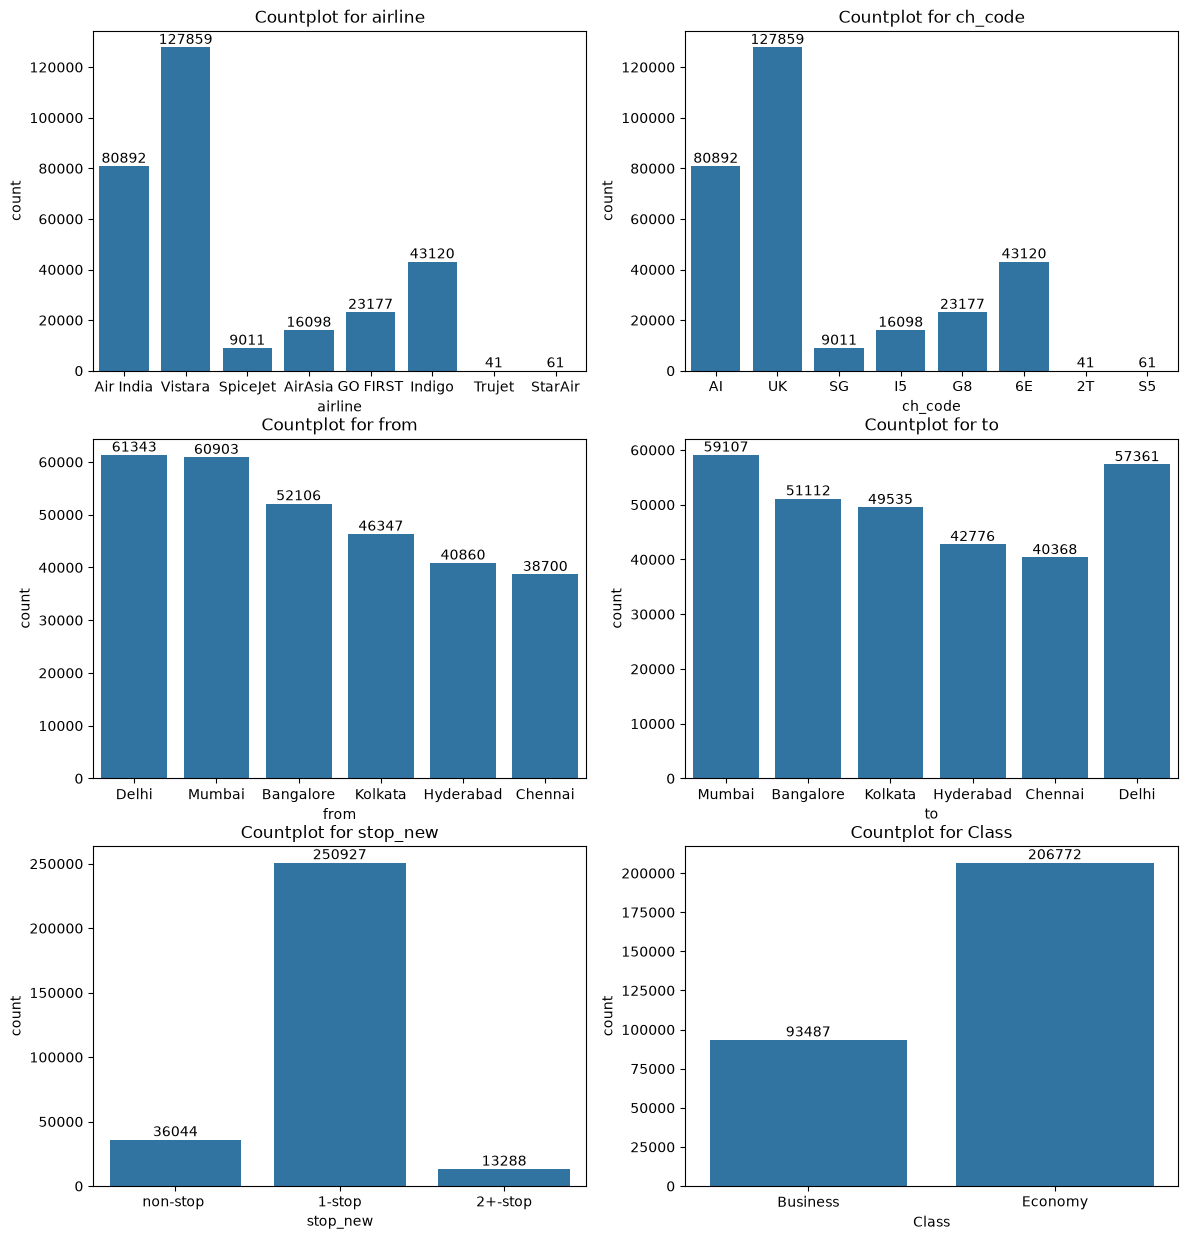

In [45]:
cols = cat_cols
plt.figure(figsize=(14,15))
for i in range(len(cols)):
    plt.subplot(3,2,i+1)
    ax = sns.countplot(data=df,x=cols[i])
    ax.bar_label(ax.containers[0])
    plt.title(f'Countplot for {cols[i]}')
plt.show()

In [46]:
num_cols

['price', 'arr_time', 'dep_time', 'num_code', 'TT_Hr', 'TT_Min']

In [47]:
df.columns

Index(['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'from',
       'time_taken', 'stop', 'arr_time', 'to', 'price', 'Class', 'TT_Hr',
       'TT_Min', 'stop_new'],
      dtype='str')

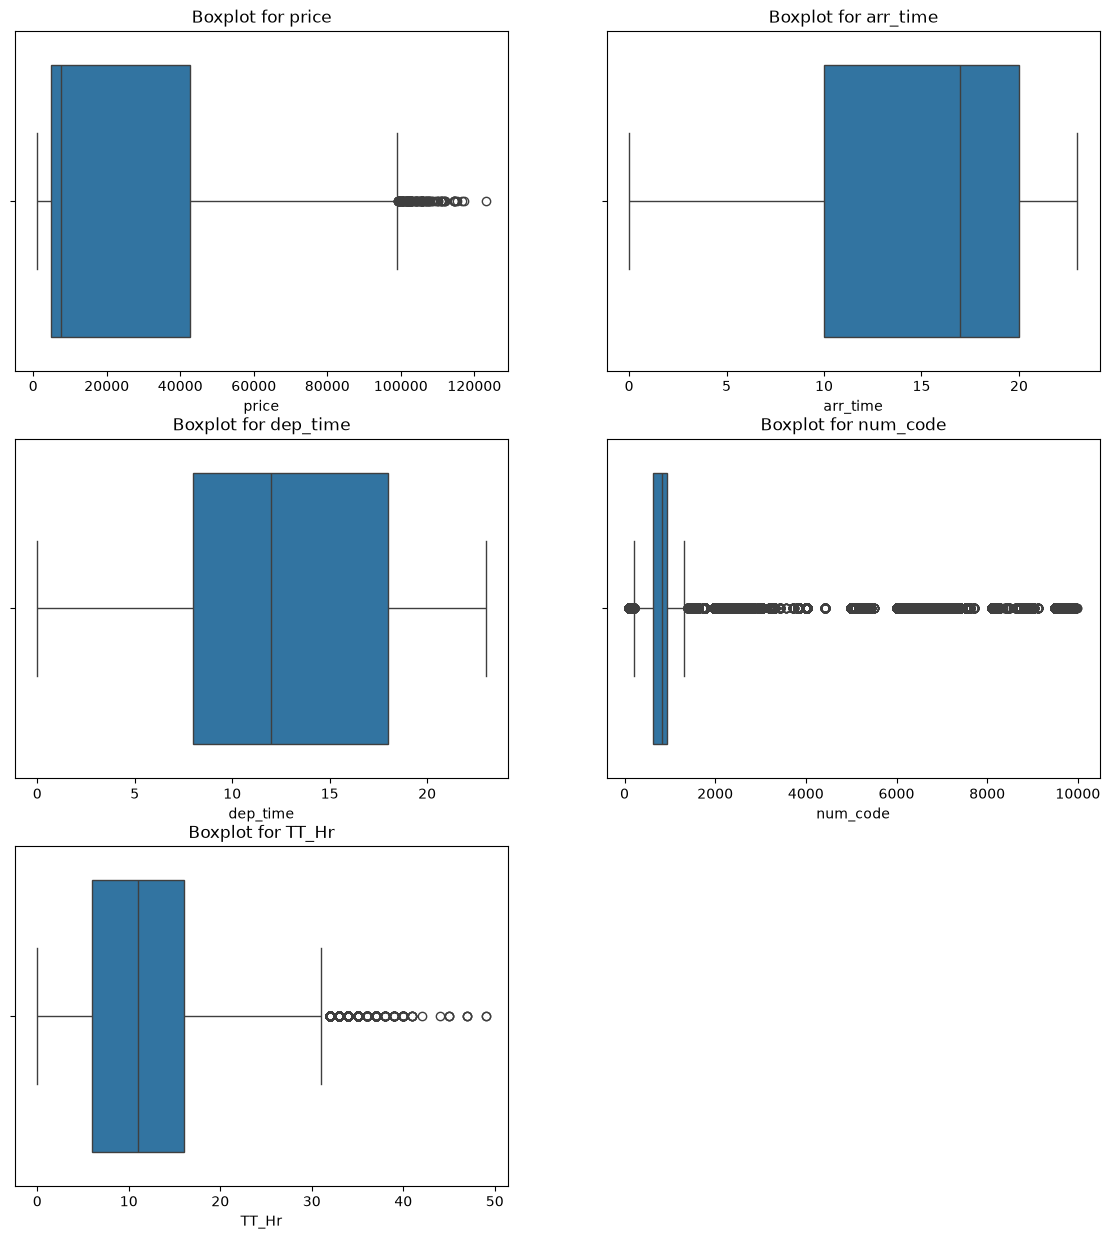

In [48]:
# num_cols = ['price','arr_time','dep_time','num_code','TT_Hr','TT_Min']

cols = num_cols[:-1]
plt.figure(figsize=(14,15))
for i in range(len(cols)):
    plt.subplot(3,2,i+1)
    sns.boxplot(data=df,x=cols[i])
    plt.title(f'Boxplot for {cols[i]}')
plt.show()

<Axes: ylabel='TT_Min'>

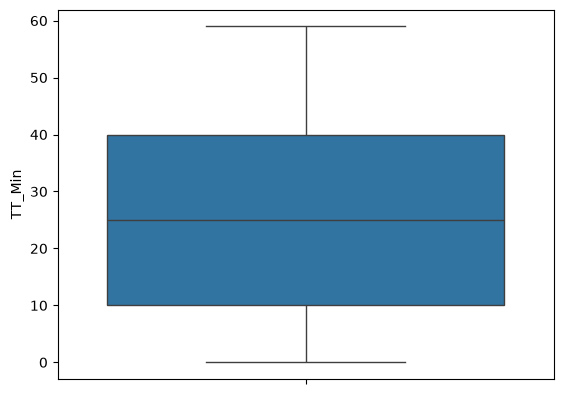

In [49]:
sns.boxplot(df['TT_Min'])

In [50]:
df['Trip_Time(min)'] = df['TT_Hr']*60 + df['TT_Min']

<Axes: ylabel='Trip_Time(min)'>

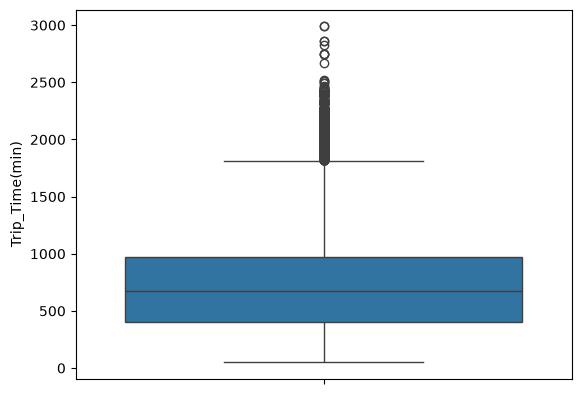

In [51]:
sns.boxplot(df['Trip_Time(min)'])

<Axes: >

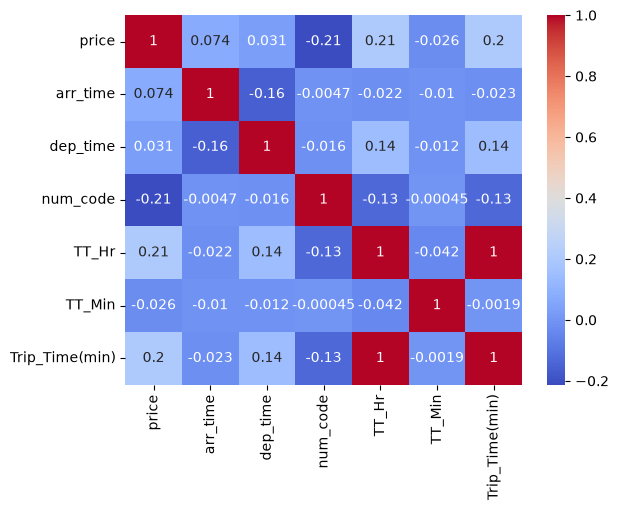

In [52]:
cols = num_cols + ['Trip_Time(min)']

corr = df[cols].corr()

sns.heatmap(corr,annot=True,cmap='coolwarm')

#### Outlier Treatment

In [53]:
w1 =  df[cols].describe(percentiles=[0.01,0.02,0.05,0.95,0.97,0.98,0.99,0.995]).T
w1 = w1.iloc[:,3:]
w1

,min,1%,2%,5%,95%,97%,98%,99%,99.5%,max
price,1105.0,1776.0,2074.0,2436.0,63277.0,67769.0,70431.0,76736.0,82205.0,123071.0
arr_time,0.0,0.0,0.0,5.0,23.0,23.0,23.0,23.0,23.0,23.0
dep_time,0.0,4.0,5.0,6.0,21.0,21.0,22.0,22.0,23.0,23.0
num_code,101.0,136.0,198.0,336.0,6513.0,7556.0,8645.0,9720.0,9891.0,9991.0
TT_Hr,0.0,1.0,1.0,2.0,25.0,26.0,27.0,29.0,31.0,49.0
TT_Min,0.0,0.0,0.0,0.0,55.0,55.0,55.0,55.0,55.0,59.0
Trip_Time(min),50.0,80.0,100.0,130.0,1555.0,1605.0,1650.0,1745.0,1870.0,2990.0


In [54]:
df[df['price']>76736.0].shape

(3000, 16)

In [55]:
df.shape

(300259, 16)

In [56]:
df[df['price']>76736.0].head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,Class,TT_Hr,TT_Min,stop_new,Trip_Time(min)
31,2022-02-11,Vistara,UK,809,19,Delhi,15h 35m,1-stop,11,Mumbai,76768,Business,15.0,35.0,1-stop,935.0
32,2022-02-11,Vistara,UK,813,17,Delhi,17h 50m,1-stop,11,Mumbai,76768,Business,17.0,50.0,1-stop,1070.0
33,2022-02-11,Vistara,UK,837,17,Delhi,18h 15m,1-stop,11,Mumbai,78376,Business,18.0,15.0,1-stop,1095.0
119,2022-02-12,Vistara,UK,737,15,Delhi,28h 25m,1-stop,20,Mumbai,77737,Business,28.0,25.0,1-stop,1705.0
120,2022-02-12,Vistara,UK,707,17,Delhi,19h 30m,1-stopVia Lucknow,13,Mumbai,79977,Business,19.0,30.0,1-stop,1170.0


In [57]:
df[df['price'] ==df['price'].max()]

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,Class,TT_Hr,TT_Min,stop_new,Trip_Time(min)
54711,2022-02-13,Vistara,UK,772,10,Kolkata,13h 30m,1-stop,23,Delhi,123071,Business,13.0,30.0,1-stop,810.0


In [58]:
df.shape

(300259, 16)

In [59]:
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,Class,TT_Hr,TT_Min,stop_new,Trip_Time(min)
0,2022-02-11,Air India,AI,868,18,Delhi,02h 00m,non-stop,20,Mumbai,25612,Business,2.0,0.0,non-stop,120.0
1,2022-02-11,Air India,AI,624,19,Delhi,02h 15m,non-stop,21,Mumbai,25612,Business,2.0,15.0,non-stop,135.0
2,2022-02-11,Air India,AI,531,20,Delhi,24h 45m,1-stop,20,Mumbai,42220,Business,24.0,45.0,1-stop,1485.0
3,2022-02-11,Air India,AI,839,21,Delhi,26h 30m,1-stop,23,Mumbai,44450,Business,26.0,30.0,1-stop,1590.0
4,2022-02-11,Air India,AI,544,17,Delhi,06h 40m,1-stop,23,Mumbai,46690,Business,6.0,40.0,1-stop,400.0


In [60]:
df['from'].unique()

<ArrowStringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Length: 6, dtype: str

In [61]:
df.isnull().sum()

date              0
airline           0
ch_code           0
num_code          0
dep_time          0
from              0
time_taken        0
stop              0
arr_time          0
to                0
price             0
Class             0
TT_Hr             0
TT_Min            4
stop_new          0
Trip_Time(min)    4
dtype: int64

In [62]:
df.columns

Index(['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'from',
       'time_taken', 'stop', 'arr_time', 'to', 'price', 'Class', 'TT_Hr',
       'TT_Min', 'stop_new', 'Trip_Time(min)'],
      dtype='str')

In [63]:
df.dtypes

date              datetime64[us]
airline                      str
ch_code                      str
num_code                   int64
dep_time                   int64
from                         str
time_taken                   str
stop                         str
arr_time                   int64
to                           str
price                      int64
Class                        str
TT_Hr                    float64
TT_Min                   float64
stop_new                  object
Trip_Time(min)           float64
dtype: object

In [64]:
df['Class'].unique()

<ArrowStringArray>
['Business', 'Economy']
Length: 2, dtype: str

In [65]:
df['Class'] = df['Class'].map({'Business':1,'Economy':0})

In [66]:
df['stop_new'] = df['stop_new'].map({'non-stop': 0,'1-stop': 1,'2+-stop': 2})

### Columns to Encode

In [67]:
df_dummies = pd.get_dummies(df,columns=['airline','from','to'],drop_first=True,dtype=int)
df_dummies.head()

,date,ch_code,num_code,dep_time,time_taken,stop,arr_time,price,Class,TT_Hr,...,from_Chennai,from_Delhi,from_Hyderabad,from_Kolkata,from_Mumbai,to_Chennai,to_Delhi,to_Hyderabad,to_Kolkata,to_Mumbai
0,2022-02-11,AI,868,18,02h 00m,non-stop,20,25612,1,2.0,...,0,1,0,0,0,0,0,0,0,1
1,2022-02-11,AI,624,19,02h 15m,non-stop,21,25612,1,2.0,...,0,1,0,0,0,0,0,0,0,1
2,2022-02-11,AI,531,20,24h 45m,1-stop,20,42220,1,24.0,...,0,1,0,0,0,0,0,0,0,1
3,2022-02-11,AI,839,21,26h 30m,1-stop,23,44450,1,26.0,...,0,1,0,0,0,0,0,0,0,1
4,2022-02-11,AI,544,17,06h 40m,1-stop,23,46690,1,6.0,...,0,1,0,0,0,0,0,0,0,1


In [68]:
df_dummies.columns

Index(['date', 'ch_code', 'num_code', 'dep_time', 'time_taken', 'stop',
       'arr_time', 'price', 'Class', 'TT_Hr', 'TT_Min', 'stop_new',
       'Trip_Time(min)', 'airline_AirAsia', 'airline_GO FIRST',
       'airline_Indigo', 'airline_SpiceJet', 'airline_StarAir',
       'airline_Trujet', 'airline_Vistara', 'from_Chennai', 'from_Delhi',
       'from_Hyderabad', 'from_Kolkata', 'from_Mumbai', 'to_Chennai',
       'to_Delhi', 'to_Hyderabad', 'to_Kolkata', 'to_Mumbai'],
      dtype='str')

In [69]:
df_dummies.dtypes

date                datetime64[us]
ch_code                        str
num_code                     int64
dep_time                     int64
time_taken                     str
stop                           str
arr_time                     int64
price                        int64
Class                        int64
TT_Hr                      float64
TT_Min                     float64
stop_new                   float64
Trip_Time(min)             float64
airline_AirAsia              int64
airline_GO FIRST             int64
airline_Indigo               int64
airline_SpiceJet             int64
airline_StarAir              int64
airline_Trujet               int64
airline_Vistara              int64
from_Chennai                 int64
from_Delhi                   int64
from_Hyderabad               int64
from_Kolkata                 int64
from_Mumbai                  int64
to_Chennai                   int64
to_Delhi                     int64
to_Hyderabad                 int64
to_Kolkata          

### Select X and Y

In [70]:
x = df_dummies.drop(['date','ch_code','num_code','time_taken','stop','price','TT_Hr', 'TT_Min'],axis=1)
y = df_dummies['price']

In [71]:
print(x.shape)
print(y.shape)

(300259, 22)
(300259,)


### Train_Test_Split

In [72]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

In [73]:
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (225194, 22)
x_test: (75065, 22)
y_train: (225194,)
y_test: (75065,)


### Linear Regression

In [78]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](22,)","[ -50.17, 75.62,45041.44,...,-1928.71, 1401.1 , -82.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](22,)","['dep_time','arr_time','Class',...,'to_Hyderabad','to_Kolkata','to_Mumbai']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-678.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,22
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(22)


In [79]:
x_train.isna().sum().sort_values(ascending=False).head(20)

dep_time            0
arr_time            0
Class               0
stop_new            0
Trip_Time(min)      0
airline_AirAsia     0
airline_GO FIRST    0
airline_Indigo      0
airline_SpiceJet    0
airline_StarAir     0
airline_Trujet      0
airline_Vistara     0
from_Chennai        0
from_Delhi          0
from_Hyderabad      0
from_Kolkata        0
from_Mumbai         0
to_Chennai          0
to_Delhi            0
to_Hyderabad        0
dtype: int64

In [80]:
x_train['stop_new'].unique()

array([1., 2.])

In [81]:
x_train = x_train.fillna(x_train.median())
x_test = x_test.fillna(x_test.median())

### Evaluation of metrics

In [82]:
ypred_lr = lr.predict(x_test)

In [83]:
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score

mae = mean_absolute_error(y_test, ypred_lr)
mse = mean_squared_error(y_test, ypred_lr)
rmse = np.sqrt(mean_squared_error(y_test, ypred_lr))
r2 = r2_score(y_test, ypred_lr)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 4748.516895402773
MSE : 53812892.53954805
RMSE: 7335.727130935831
R2  : 0.8953285524396154


In [84]:
print('Score of Linear Regression Model')
print('Train Score:', lr.score(x_train, y_train))  # Train R² Score
print('Test Score :', lr.score(x_test, y_test))    # Test R² Score

Score of Linear Regression Model
Train Score: 0.8975507272854517
Test Score : 0.8953285524396154


### Regularization (preventing model from overfitting)

## Ridge

In [85]:
from sklearn.linear_model import Ridge, Lasso, RidgeCV

In [86]:
ridge = Ridge(alpha=1)
ridge.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to

In [87]:
ypred_rid = ridge.predict(x_test)

In [88]:
print("Train Score:", ridge.score(x_train, y_train))
print("Test Score :", ridge.score(x_test, y_test))

Train Score: 0.8975507225811967
Test Score : 0.8953286724759719


## Lasso

In [89]:
lasso = Lasso(alpha=1.0)
lasso.fit(x_train, y_train)

ypred_lasso = lasso.predict(x_test)


In [90]:
print("Train Score:", lasso.score(x_train, y_train))
print("Test Score :", lasso.score(x_test, y_test))

Train Score: 0.8975426221658751
Test Score : 0.895320922111289


## RidgeCV

In [91]:
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
ridge_cv.fit(x_train, y_train)

print("Best Alpha:", ridge_cv.alpha_)

Best Alpha: 0.1


In [92]:
print("Train Score:", ridge_cv.score(x_train, y_train))
print("Test Score :", ridge_cv.score(x_test, y_test))

Train Score: 0.8975507272363444
Test Score : 0.895328565066625


### Decision Tree Regression

In [93]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [94]:
ypred_dt = dt.predict(x_test)
len(ypred_dt)

75065

In [95]:
mae_dt = mean_absolute_error(y_test, ypred_dt)
mse_dt = mean_squared_error(y_test, ypred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, ypred_dt))
r2_dt = r2_score(y_test, ypred_dt)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 4748.516895402773
MSE : 53812892.53954805
RMSE: 7335.727130935831
R2  : 0.8953285524396154


In [96]:
print('Train Score:', dt.score(x_train, y_train))  # Train R² Score
print('Test Score :', dt.score(x_test, y_test))    # Test R² Score

Train Score: 0.9800055244179953
Test Score : 0.9759667784582894


### Hyperparameter Tunning

In [97]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


In [98]:
Hparam_dt = {'criterion': ['squared_error', 'absolute_error'],
             'max_depth': [6, 7, 8, 9, 10, 15],
             'min_samples_split': [2, 8, 10, 14],
             'min_samples_leaf': [7, 9, 11, 13]}

dt_base = DecisionTreeRegressor(random_state=42)

rs = RandomizedSearchCV(estimator=dt_base, param_distributions=Hparam_dt, n_iter=20, scoring='r2', cv=5, random_state=42, n_jobs=-1)

rs.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['squared_error', 'absolute_error'], 'max_depth': [6, 7, ...], 'min_samples_leaf': [7, 9, ...], 'min_samples_split': [2, 8, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.

In [99]:
print("Best Parameters:", rs.best_params_)
print("Best CV Score:", rs.best_score_)

Best Parameters: {'min_samples_split': 8, 'min_samples_leaf': 7, 'max_depth': 15, 'criterion': 'absolute_error'}
Best CV Score: 0.9606242154234625


In [100]:
dt_best = rs.best_estimator_
ypred_dt = dt_best.predict(x_test)

In [101]:
mae_dt = mean_absolute_error(y_test, ypred_dt)
mse_dt = mean_squared_error(y_test, ypred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, ypred_dt)

print("Tuned Decision Tree")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R2  :", r2_dt)

Tuned Decision Tree
MAE : 2226.8218543928597
MSE : 20339341.88262506
RMSE: 4509.915950727359
R2  : 0.9604379497772709


In [102]:
print("Train Score:", dt_best.score(x_train,y_train))
print("Test Score:", dt_best.score(x_test,y_test))

Train Score: 0.9617940352065447
Test Score: 0.9604379497772709


### Random Forest Regression

In [103]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)
rf.fit(x_train,y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [104]:
ypred_rf = rf.predict(x_test)

In [105]:
mae_rf = mean_absolute_error(y_test, ypred_rf)
mse_rf = mean_squared_error(y_test, ypred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, ypred_rf))
r2_rf = r2_score(y_test, ypred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

Random Forest
MAE : 2124.291505748041
MSE : 12175934.774215093
RMSE: 3489.4032117562874
R2  : 0.9763165914695761


In [106]:
print('Train Score:', rf.score(x_train, y_train))  # Train R² Score
print('Test Score :', rf.score(x_test, y_test))    # Test R² Score

Train Score: 0.9798294107328135
Test Score : 0.9763165914695761


### Hyperparameter Tuning Methods

In [107]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [108]:
param_grid = {'n_estimators': [100, 200, 300, 500],
              'max_depth': [None, 10, 15, 20, 25],
              'min_samples_split': [2, 5, 10, 20],
              'min_samples_leaf': [1, 2, 4, 8],
              'max_features': ['sqrt', 'log2']}

In [109]:
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

In [110]:
random_rf = RandomizedSearchCV(estimator=rf_base, param_distributions=param_grid, n_iter=20, cv=5, scoring='r2',
            random_state=42, n_jobs=-1)

random_rf.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also fo

In [111]:
print("Best Parameters:", random_rf.best_params_)
print("Best CV Score:", random_rf.best_score_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV Score: 0.9761963968900368


In [112]:
rf_tuned = random_rf.best_estimator_

In [113]:
ypred_rf_tuned = rf_tuned.predict(x_test)

In [114]:
mae_rf = mean_absolute_error(y_test, ypred_rf_tuned)
mse_rf = mean_squared_error(y_test, ypred_rf_tuned)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, ypred_rf_tuned)

print("Tuned Random Forest")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

print("Train Score:", rf_tuned.score(x_train, y_train))
print("Test Score :", rf_tuned.score(x_test, y_test))

Tuned Random Forest
MAE : 2128.3456318938333
MSE : 12132238.308877485
RMSE: 3483.136274807158
R2  : 0.976401585456413
Train Score: 0.9797014926788712
Test Score : 0.976401585456413


### ADA BOOST Regression

In [115]:
from sklearn.ensemble import AdaBoostRegressor

In [116]:
ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
ada.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
Name,Type,Value
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeRegressor,DecisionTreeR...r(max_depth=3)
estimator_errors_ estimator_errors_: ndarray of floatsRegression error for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[0.06,0.06,0.06,...,0.37,0.36,0.43]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[0.27,0.27,0.27,...,0.05,0.06,0.03]"
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators.,list,"[DecisionTreeR...te=1608637542), DecisionTreeR...ate=801642899), DecisionTreeR...te=1083460180), DecisionTreeR...ate=694125547), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](22,)","[0. ,0. ,0.92,...,0. ,0. ,0. ]"


In [117]:
ypred_ada = ada.predict(x_test)

In [118]:
mae_ada = mean_absolute_error(y_test, ypred_ada)
mse_ada = mean_squared_error(y_test, ypred_ada)
rmse_ada = np.sqrt(mse_ada)
r2_ada = r2_score(y_test, ypred_ada)

print("AdaBoost Regressor")
print("MAE :", mae_ada)
print("MSE :", mse_ada)
print("RMSE:", rmse_ada)
print("R2  :", r2_ada)

AdaBoost Regressor
MAE : 4325.295272906812
MSE : 39060335.559716076
RMSE: 6249.826842378601
R2  : 0.924023748356862


In [119]:
print("Train Score:", ada.score(x_train, y_train))
print("Test Score :", ada.score(x_test, y_test))

Train Score: 0.923899735626541
Test Score : 0.924023748356862


In [120]:
from sklearn.model_selection import RandomizedSearchCV

In [121]:
param_ada = {'n_estimators' : [50,100,150,200,250],
             'learning_rate' : [0.01, 0.05, 0.1,0.5,1.0],
             'loss' : ['linear','square','exponential']}

In [122]:
ada_base = AdaBoostRegressor(random_state=42)
rs_ada = RandomizedSearchCV(estimator=ada_base,param_distributions=param_ada,n_iter=10,scoring='r2',cv=5,random_state=42,n_jobs=-1)
rs_ada.fit(x_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'loss': ['linear', 'square', ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the

In [125]:
ypred_ada_h = rs_ada.predict(x_test)

In [126]:
print("Best Parameters:", rs_ada.best_params_)
print("Best CV Score:", rs_ada.best_score_)

Best Parameters: {'n_estimators': 150, 'loss': 'exponential', 'learning_rate': 0.01}
Best CV Score: 0.9277797277743458


In [127]:
mae_ada_h = mean_absolute_error(y_test, ypred_ada_h)
mse_ada_h = mean_squared_error(y_test, ypred_ada_h)
rmse_ada_h = np.sqrt(mse_ada_h)
r2_ada_h = r2_score(y_test, ypred_ada_h)

print("AdaBoost Regressor")
print("MAE :", mae_ada_h)
print("MSE :", mse_ada_h)
print("RMSE:", rmse_ada_h)
print("R2  :", r2_ada_h)

AdaBoost Regressor
MAE : 4047.0174686460628
MSE : 37148072.01526139
RMSE: 6094.92182191547
R2  : 0.9277432918318373


In [128]:
print("Train Score:", ada.score(x_train, y_train))
print("Test Score :", ada.score(x_test, y_test))

Train Score: 0.923899735626541
Test Score : 0.924023748356862


### KNN Regression

In [129]:
from sklearn.neighbors import KNeighborsRegressor

In [130]:
knn = KNeighborsRegressor(n_neighbors=5, weights = 'uniform', p = 2)
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [131]:
ypred_knn = knn.predict(x_test)

In [132]:
mae_knn = mean_absolute_error(y_test,ypred_knn)
mse_knn = mean_squared_error(y_test, ypred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, ypred_knn)


print("KNN Regressor")
print("MAE :", mae_knn)
print("MSE :", mse_knn)
print("RMSE:", rmse_knn)
print("R2  :", r2_knn)

KNN Regressor
MAE : 2780.0708719110103
MSE : 29272229.347100247
RMSE: 5410.381626752428
R2  : 0.943062591983347


In [133]:
print("Train Score:", knn.score(x_train, y_train))
print("Test Score :", knn.score(x_test, y_test))

Train Score: 0.9592352667425127
Test Score : 0.943062591983347


### Hyperparameters Tunning

In [134]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [137]:
param_knn = {'n_neighbors' : [3,5,7,9,11,15,20],
               'weights': ['uniform', 'distance'],
               'p': [1,2]}
rs_knn = RandomizedSearchCV(estimator = KNeighborsRegressor(),param_distributions= param_knn, 
                            n_iter = 10, scoring = 'r2', cv= 5, random_state= 42, n_jobs =-1)
rs_knn.fit(x_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_

In [136]:
print("Best Parameters:", rs_knn.best_params_)
print("Best CV Score:", rs_knn.best_score_)

Best Parameters: {'weights': 'distance', 'p': 1, 'n_neighbors': 20}
Best CV Score: 0.9676304096730902


In [138]:
print("Train Score:", rs_knn.score(x_train, y_train))
print("Test Score :", rs_knn.score(x_test, y_test))

Train Score: 0.9796928628724706
Test Score : 0.9705083798767344


In [139]:
from xgboost import XGBRegressor

In [142]:
xgb = XGBRegressor(n_estimators= 100, learning_rate = 0.1, max_depth= 6, random_state = 42)
xgb.fit(x_train,y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [143]:
ypred_xgb = xgb.predict(x_test)

In [144]:
mae_xgb = mean_absolute_error(y_test, ypred_xgb)
mse_xgb = mean_squared_error(y_test, ypred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, ypred_xgb)

print("XGBoost Regressor")
print("MAE :", mae_xgb)
print("MSE :", mse_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

print("Train Score:", xgb.score(x_train, y_train))
print("Test Score :", xgb.score(x_test, y_test))

XGBoost Regressor
MAE : 3027.060546875
MSE : 20732720.0
RMSE: 4553.31966811029
R2  : 0.9596728086471558
Train Score: 0.9604382514953613
Test Score : 0.9596728086471558


### Hyperparametrics Tunning

In [145]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [146]:
Hparam_xgb = {'n_estimators': [100,200,300,400,500],
             'max_depth': [3,5,7,10,15],
             'learning_rate':[0.01,0.05,0.1,0.2],
             'subsample': [0.7, 0.8, 1.0],
             'cosample_bytree': [0.7,0.8,0.9,1.0]}

In [151]:
xgb_base = XGBRegressor(objective='reg:squarederror',random_state = 42)

In [154]:
rs_xgb = RandomizedSearchCV(estimator=xgb_base, param_distributions=Hparam_xgb, n_iter=20, scoring='r2', cv=5,
    random_state=42, n_jobs=-1)
rs_xgb.fit(x_train, y_train)

C:\Users\ayush\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:20:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "cosample_bytree" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'cosample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also 

In [155]:
print("Best Parameters:", rs_xgb.best_params_)
print("Best CV Score:", rs_xgb.best_score_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.2, 'cosample_bytree': 1.0}
Best CV Score: 0.9763095259666443


In [156]:
xgb_best = rs_xgb.best_estimator_

In [157]:
ypred_xgb = xgb_best.predict(x_test)

In [158]:
mae_xgb = mean_absolute_error(y_test, ypred_xgb)
mse_xgb = mean_squared_error(y_test, ypred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, ypred_xgb)

print("MAE :", mae_xgb)
print("MSE :", mse_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

print("Train Score:", xgb_best.score(x_train, y_train))
print("Test Score :", xgb_best.score(x_test, y_test))

MAE : 2141.307861328125
MSE : 12116742.0
RMSE: 3480.911087632087
R2  : 0.9764317274093628
Train Score: 0.9797771573066711
Test Score : 0.9764317274093628


In [159]:
import pickle
pickle.dump(lr, open('flight_price_linear_regression_Second.pkl', 'wb'))